In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [3]:
class_names=["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
X_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


In [5]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
])


In [6]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EarlyStopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=10,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)


In [9]:


model.fit(x_train, y_train, epochs=50, batch_size=64, validation_split=0.1, callbacks=EarlyStopping)

Epoch 1/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8006 - loss: 0.5507 - val_accuracy: 0.8598 - val_loss: 0.3676
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8705 - loss: 0.3579 - val_accuracy: 0.8830 - val_loss: 0.3153
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8864 - loss: 0.3110 - val_accuracy: 0.8958 - val_loss: 0.2774
Epoch 4/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8965 - loss: 0.2810 - val_accuracy: 0.9042 - val_loss: 0.2611
Epoch 5/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9047 - loss: 0.2588 - val_accuracy: 0.9062 - val_loss: 0.2502
Epoch 6/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9121 - loss: 0.2385 - val_accuracy: 0.9090 - val_loss: 0.2464
Epoch 7/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9178 - loss: 0.2219 - val_accuracy: 0.9128 - val_loss: 0.2362
Epoch 8/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9216 - loss: 0.2075 - val_accuracy: 0.

In [11]:
x_test = x_test.astype("float32")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}")

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [12]:
predictions = model.predict(x_test[:9], verbose=0)

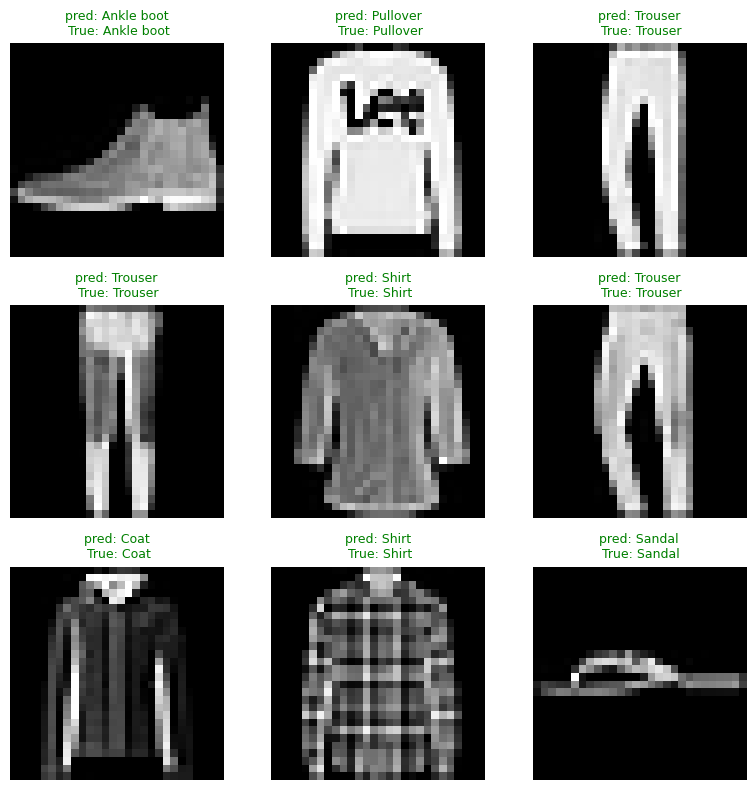

In [13]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    predicted = class_names[np.argmax(predictions[i])]
    actual = class_names[y_test[i]]
    color = "green" if predicted == actual else "red"
    plt.title(f"pred: {predicted}\n True: {actual}", color=color, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.savefig("prediction.png")
plt.show()



In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report

In [15]:
y_prob = model.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)  

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [16]:
print(f"\n precision: {precision_score(y_test, y_pred, average="macro")}")
print(f"\n recall: {recall_score(y_test, y_pred, average="macro")}")
print(f"\nF1 score: {f1_score(y_test, y_pred, average="macro")}")
print(f"\nMCC: {matthews_corrcoef(y_test, y_pred)}")
print(classification_report(y_test, y_pred, digits=4))




 precision: 0.9154727387973753

 recall: 0.9151

F1 score: 0.9150624871409366

MCC: 0.9057208203270996
              precision    recall  f1-score   support

           0     0.8758    0.8530    0.8642      1000
           1     0.9959    0.9800    0.9879      1000
           2     0.8916    0.8640    0.8776      1000
           3     0.9161    0.9170    0.9165      1000
           4     0.8315    0.9030    0.8658      1000
           5     0.9801    0.9830    0.9815      1000
           6     0.7610    0.7450    0.7529      1000
           7     0.9482    0.9700    0.9590      1000
           8     0.9771    0.9800    0.9785      1000
           9     0.9775    0.9560    0.9666      1000

    accuracy                         0.9151     10000
   macro avg     0.9155    0.9151    0.9151     10000
weighted avg     0.9155    0.9151    0.9151     10000



In [17]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test, y_prob, multi_class="ovr"))

0.9943928055555556


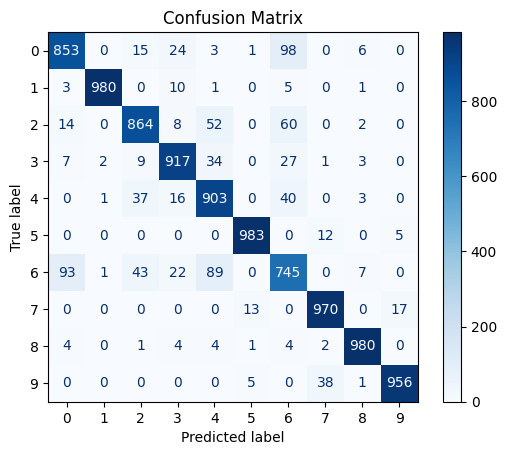

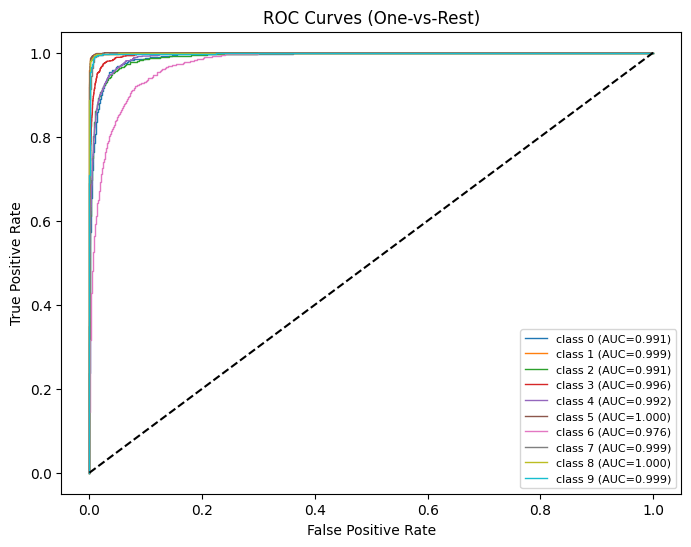

In [18]:
from sklearn.preprocessing import label_binarize
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

n_classes = y_prob.shape[1]
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, lw=1, label=f"class {i} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(fontsize=8)
plt.show()

C:\Users\lenovo\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\lenovo\miniconda3\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
C:\Users\lenovo\miniconda3\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 28, 28, 1))']
  warnings.warn(msg)
C:\Users\lenovo\miniconda3\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(

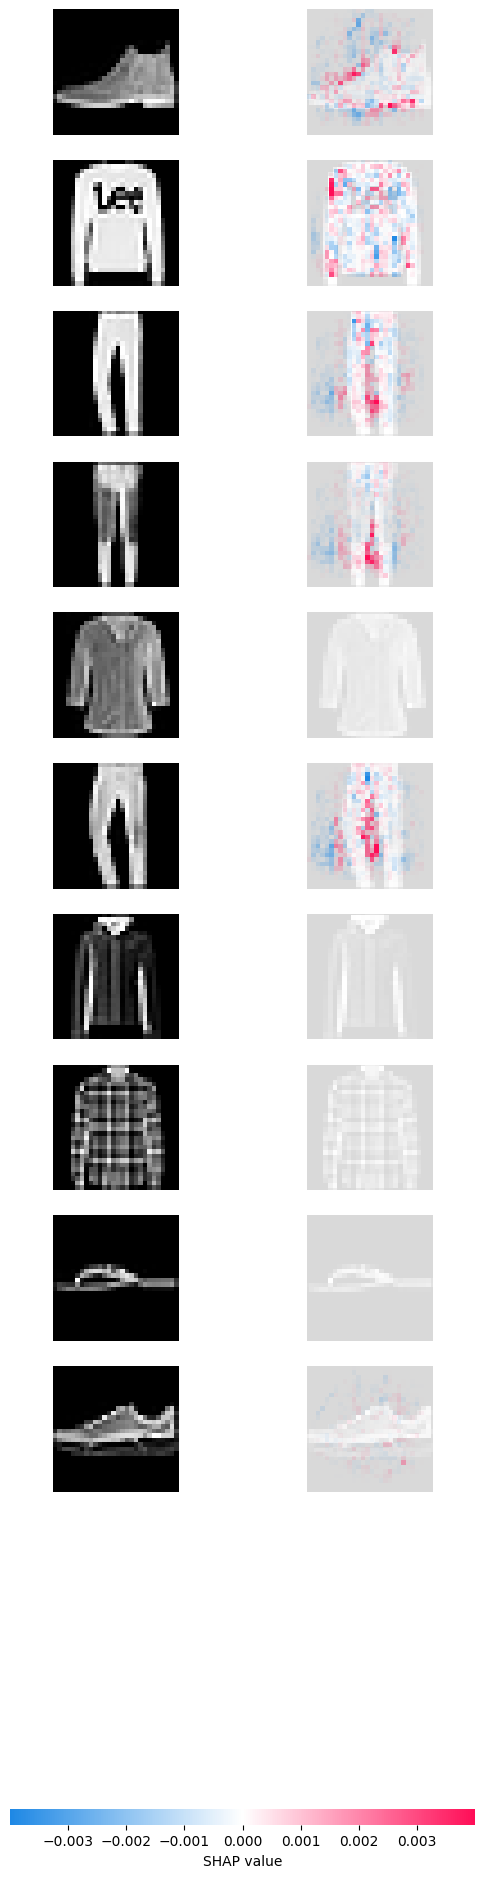

In [19]:
if x_train.ndim == 3:
    x_train = x_train[..., np.newaxis]   # (N, 28, 28) -> (N, 28, 28, 1)
if x_test.ndim == 3:
    x_test = x_test[..., np.newaxis]

import shap

background = x_train[np.random.choice(len(x_train), 100, replace=False)]

try:
    explainer = shap.DeepExplainer(model, background)
except Exception:
    explainer=shap.GradientExplainer(model, background)

test_sample = x_test[:10]
shap_values = explainer.shap_values(test_sample)

shap.image_plot(shap_values, test_sample)


  0%|                                                                                         | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


  2%|█▌                                                                             | 20/1000 [00:00<00:07, 128.85it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


  4%|███▏                                                                           | 40/1000 [00:00<00:06, 148.73it/s]

...

 96%|██████████████████████████████████████████████████████████████████████████▉   | 960/1000 [00:05<00:00, 175.04it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


 98%|████████████████████████████████████████████████████████████████████████████▍ | 980/1000 [00:05<00:00, 155.89it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:06<00:00, 164.18it/s]


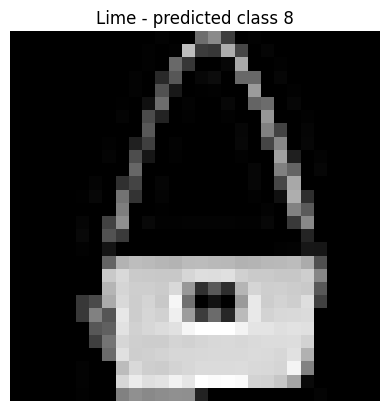

In [20]:
from lime import lime_image

from skimage.segmentation import mark_boundaries

explainer_lime = lime_image.LimeImageExplainer()

def predict_fn(images):
    gray = images[..., :1].astype("float32")
    return model.predict(gray)

idx = 31
img = x_test[idx].squeeze()
img_rgb = np.stack([img]*3, axis=-1)

explanation = explainer_lime.explain_instance(img_rgb,
                                               predict_fn,
                                               top_labels=3,
                                               num_samples=1000,
                                               hide_color=0
                                              )

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=8,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp, mask))
plt.title(f"Lime - predicted class {explanation.top_labels[0]}")
plt.axis("off")
plt.show()

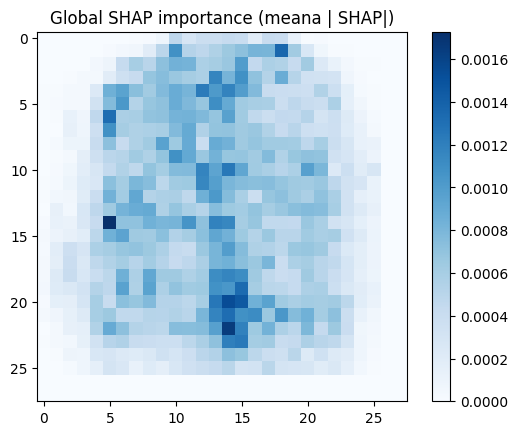

In [21]:
import time

sv = np.array(shap_values)
if isinstance(shap_values, list):
    sv = np.stack(shap_values, axis=-1)


global_importance = np.abs(sv).mean(axis=(0,-1)).squeeze()

plt.imshow(global_importance, cmap="Blues")
plt.colorbar();
plt.title("Global SHAP importance (meana | SHAP|)")
plt.show()

In [27]:
from scipy.stats import spearmanr
from lime.wrappers.scikit_image import SegmentationAlgorithm
segmenter = SegmentationAlgorithm("slic", n_segments=50, compactness=1)

def compare_instance(idx, target_class):
    shap_map = sv[idx, ..., target_class].squeeze()

    img_rgb = np.stack([x_test[idx].squeeze()]*3, axis=-1)
    exp = explainer_lime.explain_instance(
        img_rgb, predict_fn, labels=(target_class,),
        num_samples=2000, hide_color=0, segmentation_fn=segmenter)

    segments = exp.segments
    lime_weights = dict(exp.local_exp[target_class])

    seg_ids = sorted(lime_weights.keys())
    shap_agg = [shap_map[segments ==s].sum() for s in seg_ids]
    lime_agg = [lime_weights[s] for s in seg_ids]


    rho, p = spearmanr(shap_agg, lime_agg)
    return rho, p, exp

rhos = []
for i in range(1):
    target = int(y_pred[i])
    rho, p, exp = compare_instance(i, target)
    rhos.append(rho)
    print(f"Instance {i}: spearman p = {rho:.3f} (p={p:.3f})")
print(f"Mean p: {np.mean(rhos):.3f}")
    

  0%|                                                                                         | 0/2000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


  1%|▊                                                                              | 20/2000 [00:00<00:14, 135.08it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


  2%|█▌                                                                             | 40/2000 [00:00<00:13, 145.61it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


 99%|████████████████████████████████████████████████████████████████████████████▏| 1980/2000 [00:11<00:00, 180.84it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:11<00:00, 171.40it/s]

Instance 0: spearman p = 0.459 (p=0.011)
Mean p: 0.459


In [28]:
print("LIME local fidelity (R²):", exp.score)

LIME local fidelity (R²): 0.5301275801888028


In [29]:
def deletion_fidelity(idx, target_class, attribution_map, k_frac=0.2):
    img = x_test[idx].copy()
    flat = np.abs(attribution_map).flatten()
    k = int(len(flat) * k_frac)
    top_idx = np.argsort(flat)[-k:]                # top 20% pixels

    p_orig = model.predict(img[np.newaxis], verbose=0)[0, target_class]
    masked = img.flatten().copy()
    masked[top_idx] = 0
    p_masked = model.predict(masked.reshape(img.shape)[np.newaxis], verbose=0)[0, target_class]
    return p_orig - p_masked                       # bigger drop = more faithful

drop = deletion_fidelity(0, int(y_pred[0]), sv[0, ..., int(y_pred[0])].squeeze())
print(f"SHAP deletion fidelity: prob drop = {drop:.4f}")

SHAP deletion fidelity: prob drop = 0.4252
